## Daily Fourier-coefficient amplitudes in NoRad and CldRad


### Import package

In [1]:
import h5py
import numpy as np

from typing import cast, Dict
from pathlib import Path

from matplotlib import pyplot as plt

# Match the growth-rate and phase-speed contrast figures.
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "legend.fontsize": 12,
    "figure.titlesize": 18,
})

FIG_DIR = Path("/home/b11209013/Manuscript_Prep/KW_CRI/Figure/experiment_contrast")
FIG_DIR.mkdir(parents=True, exist_ok=True)

EXPERIMENT_STYLES = {
    "norad": {"label": "NoRad", "color": "#0072B2", "linestyle": "-", "marker": "o"},
    "cldrad": {"label": "CldRad", "color": "#D55E00", "linestyle": "--", "marker": "s"},
}
ENSEMBLE_INDEX = 0  # Preserve the first ensemble member shown in the original plots.


### Load NoRad and CldRad Fourier state

In [2]:
# input path
INPUT_PATH: Path = Path("/work/b11209013/Kuang2008_v0.5.0/full")

# Load NoRad
q: Dict[str, np.ndarray] = {}
J2: Dict[str, np.ndarray] = {}

with h5py.File(INPUT_PATH / "NoRad/State.h5", "r") as norad_ds:

    q["norad"] = cast(h5py.Dataset, norad_ds["q"])[...]
    J2["norad"] = cast(h5py.Dataset, norad_ds["J2"])[...]

with h5py.File(INPUT_PATH / "CldRad/State.h5", "r") as cldrad_ds:

    q["cldrad"] = cast(h5py.Dataset, cldrad_ds["q"])[...]
    J2["cldrad"] = cast(h5py.Dataset, cldrad_ds["J2"])[...]

The arrays have dimensions `(time, ensemble)`. The plots retain ensemble index
`0` and the existing daily averaging: average each block of four complex samples,
then take its magnitude. This is **amplitude**, not variance or the daily mean of
instantaneous magnitudes. Incomplete final blocks are omitted.

The horizontal coordinate is the zero-based daily-mean index, retaining the
original plots' time origin. Units are not provided in the input datasets, so
amplitudes are shown in original data units.


### Calculate daily mean of the two variables

In [3]:
q_daily: Dict[str, np.ndarray] = {
    key: np.array([
        q[key][i*4:(i+1)*4].mean(axis=0)
        for i in range(q[key].shape[0]//4)
    ])
    for key in q.keys()
}

J2_daily: Dict[str, np.ndarray] = {
    key: np.array([
        J2[key][i*4:(i+1)*4].mean(axis=0)
        for i in range(J2[key].shape[0]//4)
    ])
    for key in J2.keys()
}

### Plot daily-mean coefficient amplitudes


In [4]:
def plot_coefficient_contrast(daily_values, symbol, title, filename):
    """Plot one ensemble member using the shared experiment-contrast style."""
    fig, ax = plt.subplots(figsize=(8, 5), dpi=140, layout="constrained")
    for experiment, style in EXPERIMENT_STYLES.items():
        amplitude = np.abs(daily_values[experiment][:, ENSEMBLE_INDEX])
        days = np.arange(amplitude.size)
        ax.plot(
            days, np.ma.masked_invalid(amplitude),
            linewidth=2, markersize=4,
            markevery=max(1, amplitude.size // 20), **style,
        )

    ax.set(
        xlabel="Day (daily-mean index)",
        ylabel=rf"$|\overline{{{symbol}}}|$ [original data units]",
        title=title,
    )
    ax.set_ylim(bottom=0)
    ax.margins(x=0.02)
    ax.minorticks_on()
    ax.tick_params(axis="both", which="both", direction="in")
    ax.set_axisbelow(True)
    ax.grid(True, color="0.88", linewidth=0.7)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False)

    fig.savefig(FIG_DIR / f"{filename}.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{filename}.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)


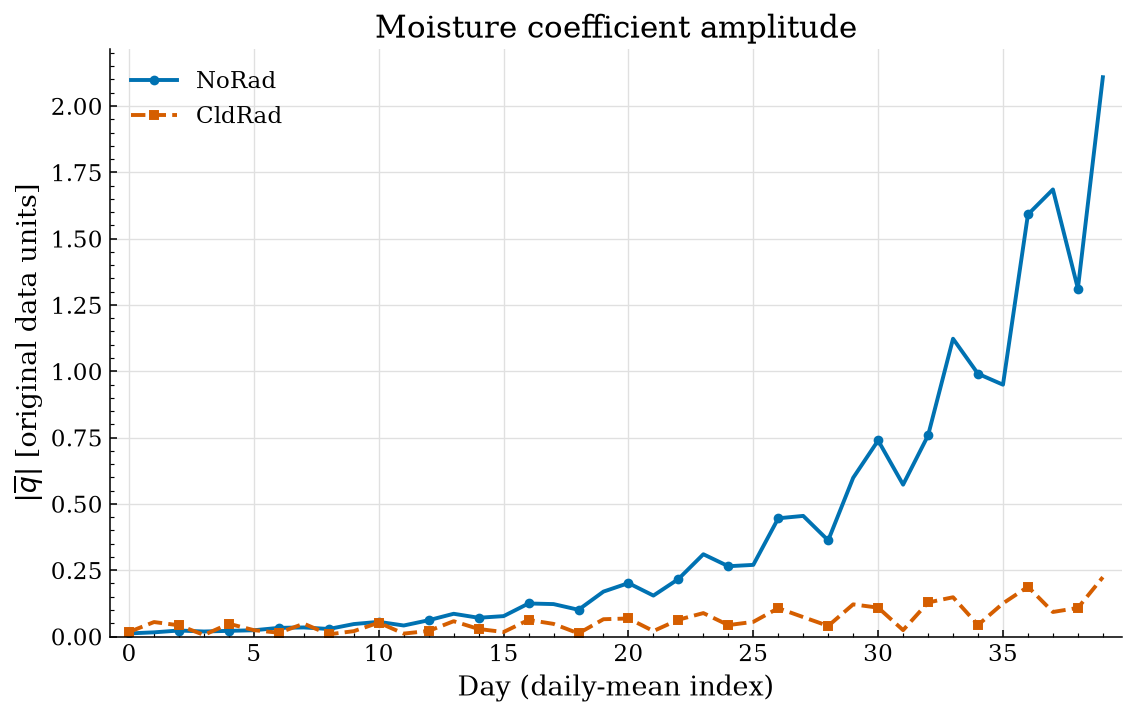

In [5]:
plot_coefficient_contrast(
    q_daily, symbol="q", title="Moisture coefficient amplitude",
    filename="q_coeff_contrast",
)


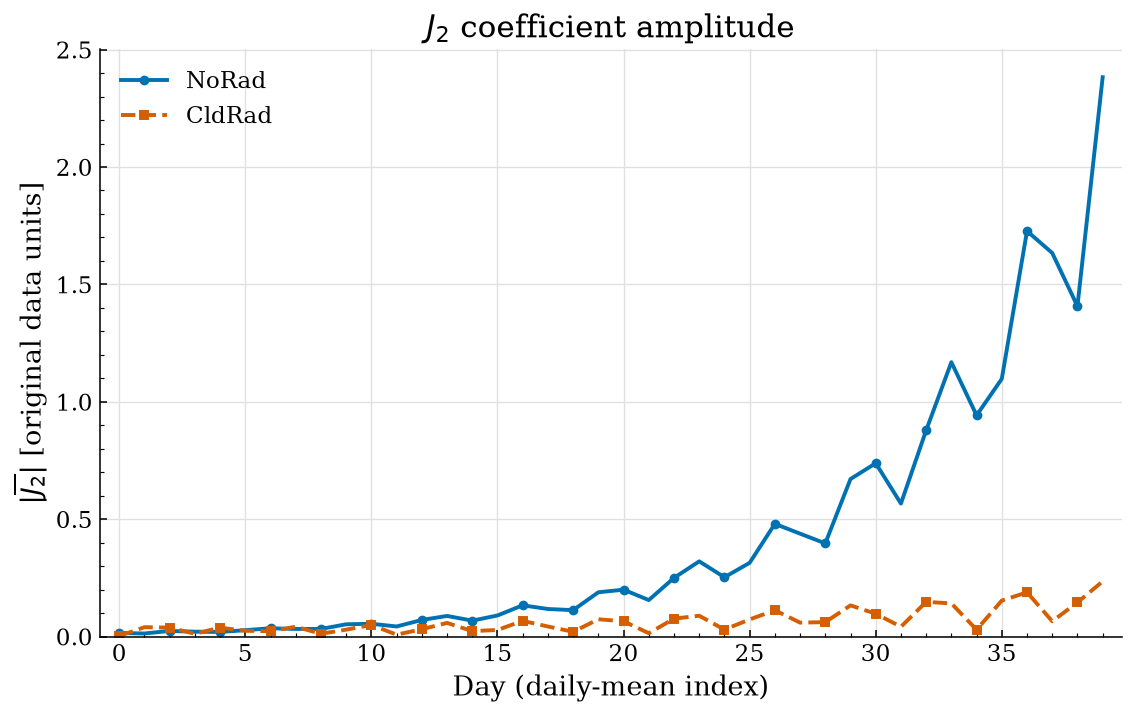

In [6]:
plot_coefficient_contrast(
    J2_daily, symbol="J_2", title=r"$J_2$ coefficient amplitude",
    filename="J2_coeff_contrast",
)
